In [7]:
from ultralytics import YOLO

model_path = "../Models/yolov8n.pt"
model = YOLO(model_path)

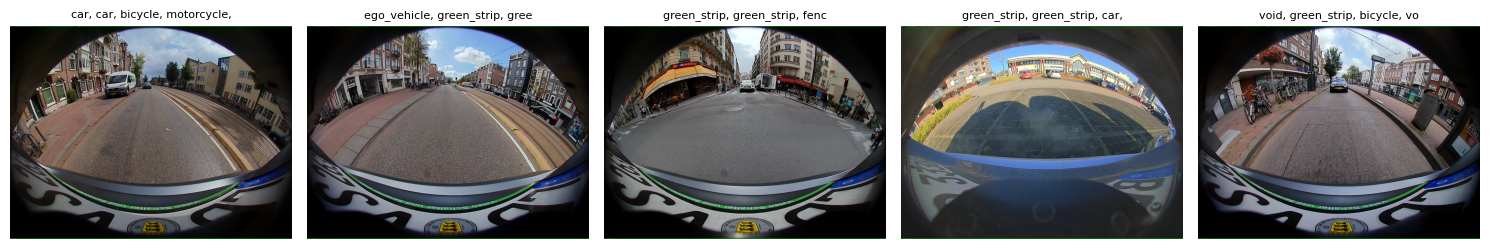

In [8]:
import os
import random
import json
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np 
from pathlib import Path


base_dir = Path.cwd().parent
data_dir = base_dir / "Data"

train_img_path = data_dir / "train" / "img"
train_ann_path = data_dir / "train" / "ann"


RV_images = [p for p in os.listdir(train_img_path) if "_RV" in os.path.splitext(os.path.basename(p))[0]]
test_images = random.sample(RV_images, 5)

with open("test_images.json","w") as f:
    json.dump(test_images, f)

plt.figure(figsize=(15, 10))
for i, img_name in enumerate(test_images):
    img_path = os.path.join(train_img_path, img_name)
    image = Image.open(img_path)

    # Match JSON annotation file
    ann_name = img_name + ".json"
    ann_path = os.path.join(train_ann_path, ann_name)

    label_text = "No label file"
    if os.path.exists(ann_path):
        with open(ann_path, 'r') as f:
            ann_data = json.load(f)
            if 'objects' in ann_data:
                # Get the class titles
                labels = [obj.get('classTitle', 'unknown') for obj in ann_data['objects']]
                label_text = ', '.join(labels) if labels else "No objects found"

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(label_text[:30], fontsize=8)
    plt.axis('off')
    

plt.tight_layout()
plt.show()


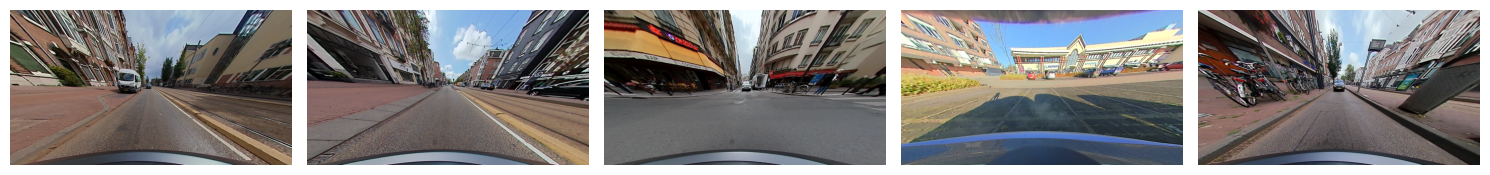

In [9]:

# Original intrinsics   
K = np.array([
    [350.0, 0.0, 640.0],  # fx, 0, cx
    [0.0, 350.0, 483.0],  # 0, fy, cy
    [0.0, 0.0, 1.0]
])
D = np.array([-0.01, 0.01, -0.001, 0.0005])  # fisheye distortion coefficients

def init_undistort_maps(K, D, image_size, balance, scale):
    w, h = image_size

    # New camera matrix with adjustable scaling
    new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        K, D, (w, h), np.eye(3), balance=balance, new_size=(w, h), fov_scale=scale
    )

    map1, map2 = cv2.fisheye.initUndistortRectifyMap(
        K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2
    )
    return map1, map2, new_K

# Adjust these to tune how much of the fisheye edge is preserved
map1, map2, new_K = init_undistort_maps(K, D, (1280, 966), balance=0.8, scale=0.22)

def undistort_fisheye(image, map1, map2):
    return cv2.remap(image, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

# Load your image list
with open("test_images.json", "r") as f:
    test_images = json.load(f)

# Output folder
output_folder = base_dir / "Notebooks" / "RV_undistorted_results"
output_folder.mkdir(exist_ok=True)

# Clear output folder
for p in output_folder.iterdir():
    if p.is_file():
        p.unlink()
os.makedirs(output_folder, exist_ok=True)

# Optional: clear folder
for file in os.listdir(output_folder):
    os.remove(os.path.join(output_folder, file))

plt.figure(figsize=(15, 10))

for i, img_name in enumerate(test_images):
    img = cv2.imread(os.path.join(train_img_path, img_name))
    und = undistort_fisheye(img, map1, map2)

    h = und.shape[0]
    # crop the bottom 27% to remove the camera body (because it would sometimes detect it as a car)
    und = und[: int(h * 0.73) ]   

    cv2.imwrite(os.path.join(output_folder, img_name), und)
    plt.subplot(1, len(test_images), i+1)
    plt.imshow(cv2.cvtColor(und, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()



Processing: c:\Senior Research Project 2025-2026\Data\train\img\rgb_03224_RV.png
Processing: c:\Senior Research Project 2025-2026\Data\train\img\rgb_02022_RV.png
Processing: c:\Senior Research Project 2025-2026\Data\train\img\rgb_05867_RV.png
Processing: c:\Senior Research Project 2025-2026\Data\train\img\rgb_06252_RV.png
Processing: c:\Senior Research Project 2025-2026\Data\train\img\rgb_01872_RV.png


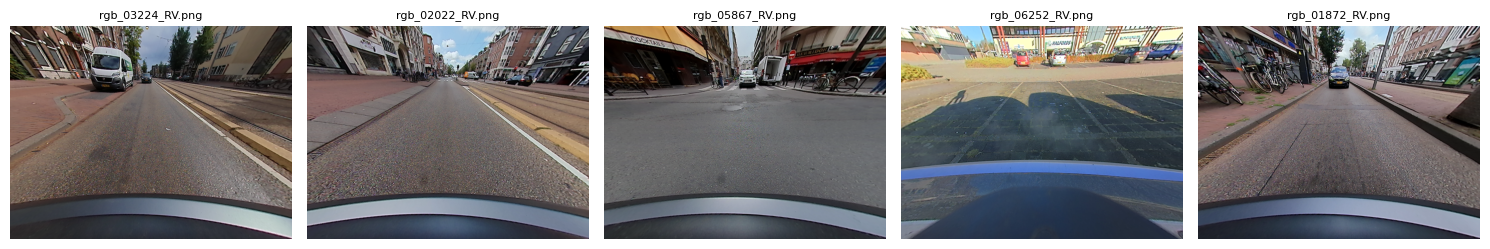


All undistorted images saved to: c:\Senior Research Project 2025-2026\Notebooks\RV_undistorted_results


In [10]:
#
# TODO: different undistortion not as good as the one above so it is not saved 
#
#

import os, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# --- Camera intrinsics ---
K = np.array([
    [350.0, 0.0, 640.0],
    [0.0, 350.0, 483.0],
    [0.0, 0.0, 1.0]
])
D = np.array([-0.01, 0.01, -0.001, 0.0005])

def init_undistort_maps(K, D, image_size):
    w, h = image_size
    map1, map2 = cv2.fisheye.initUndistortRectifyMap(
        K, D, np.eye(3), K, (w, h), cv2.CV_16SC2
    )
    return map1, map2

map1, map2 = init_undistort_maps(K, D, (1280, 966))

def undistort_fisheye(image, map1, map2):
    return cv2.remap(image, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)


# load list
with open(base_dir / "Notebooks" / "test_images.json", "r") as f:
    test_images = json.load(f)

plt.figure(figsize=(15, 6))

for i, img_name in enumerate(test_images):
    img_path = train_img_path / img_name
    print(f"Processing: {img_path}")

    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print("  ⚠️ Could not read image:", img_path)
        continue

    undist_bgr = undistort_fisheye(img_bgr, map1, map2)

    # Convert for matplotlib
    undist_rgb = cv2.cvtColor(undist_bgr, cv2.COLOR_BGR2RGB)

    # Show
    plt.subplot(1, len(test_images), i + 1)
    plt.imshow(undist_rgb)
    plt.title(img_name[:20], fontsize=8)
    plt.axis("off")



plt.tight_layout()
plt.show()

print(f"\nAll undistorted images saved to: {output_folder}")



🔍 Running detection on: rgb_01872_RV.png

image 1/1 c:\Senior Research Project 2025-2026\Notebooks\RV_undistorted_results\rgb_01872_RV.png: 352x640 1 car, 69.6ms
Speed: 35.2ms preprocess, 69.6ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.68


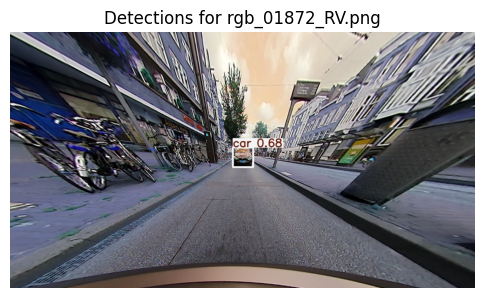


🔍 Running detection on: rgb_02022_RV.png

image 1/1 c:\Senior Research Project 2025-2026\Notebooks\RV_undistorted_results\rgb_02022_RV.png: 352x640 4 cars, 44.3ms
Speed: 1.9ms preprocess, 44.3ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.43
  - car             conf: 0.41
  - car             conf: 0.38
  - car             conf: 0.36


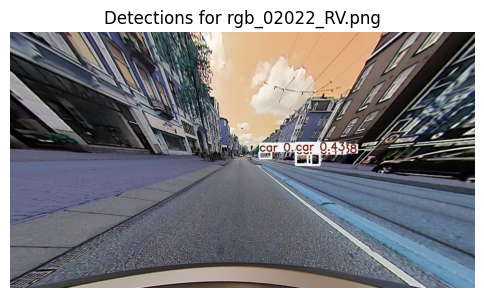


🔍 Running detection on: rgb_03224_RV.png

image 1/1 c:\Senior Research Project 2025-2026\Notebooks\RV_undistorted_results\rgb_03224_RV.png: 352x640 1 car, 1 bus, 48.9ms
Speed: 2.0ms preprocess, 48.9ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.67
  - bus             conf: 0.48


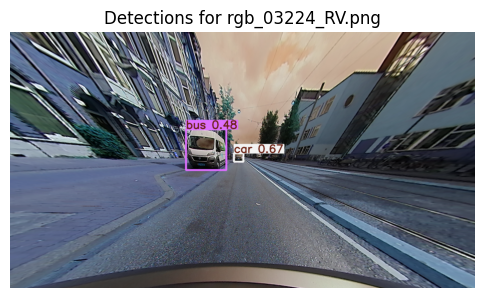


🔍 Running detection on: rgb_05867_RV.png

image 1/1 c:\Senior Research Project 2025-2026\Notebooks\RV_undistorted_results\rgb_05867_RV.png: 352x640 1 car, 1 truck, 1 kite, 75.6ms
Speed: 2.1ms preprocess, 75.6ms inference, 0.8ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.70
  - kite            conf: 0.58
  - truck           conf: 0.44


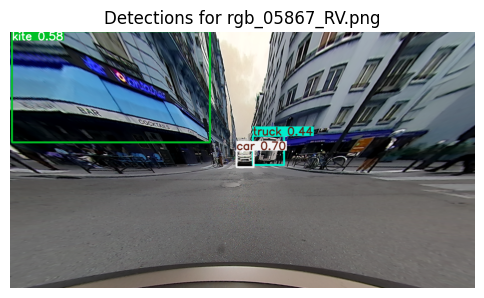


🔍 Running detection on: rgb_06252_RV.png

image 1/1 c:\Senior Research Project 2025-2026\Notebooks\RV_undistorted_results\rgb_06252_RV.png: 352x640 1 car, 53.6ms
Speed: 1.6ms preprocess, 53.6ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)
  - car             conf: 0.27


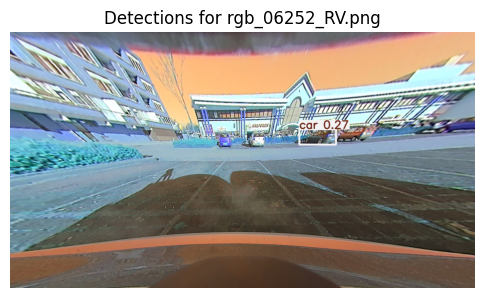

In [11]:
# Folder with your undistorted RV PNGs

rv_undistorted_dir = base_dir / "Notebooks" / "RV_undistorted_results"

test_images = [f for f in os.listdir(rv_undistorted_dir)]

for img_file in test_images:
    img_path = os.path.join(rv_undistorted_dir, img_file)
    print(f"\n🔍 Running detection on: {img_file}")
    results = model(img_path, verbose=True)  # set verbose=True if you want full YOLO logs

    # results[0] contains one image's detection info
    for box in results[0].boxes:
        cls_id = int(box.cls)                     # class ID
        conf = float(box.conf)                    # confidence
        cls_name = model.names[cls_id]            # class name (like car, person, etc.)
        print(f"  - {cls_name:<15} conf: {conf:.2f}")

    plotted = results[0].plot()                   # draws boxes + labels on image
    plt.figure(figsize=(6, 4))
    plt.imshow(plotted)
    plt.title(f"Detections for {img_file}")
    plt.axis('off')
    plt.show()


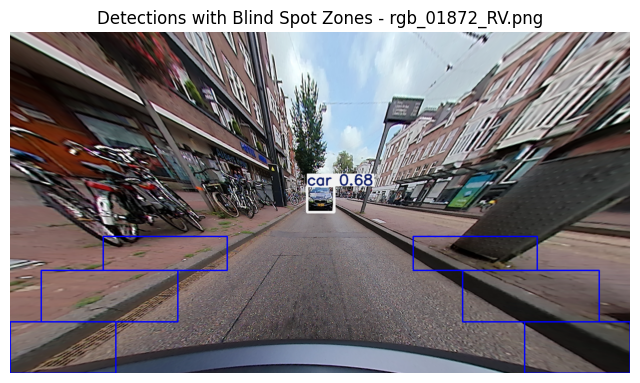

 No cars in blind spots.


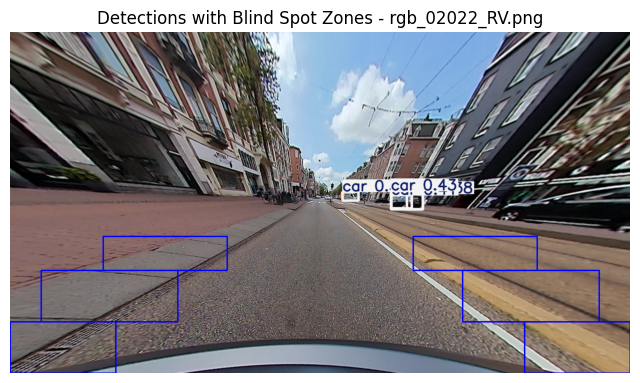

 No cars in blind spots.


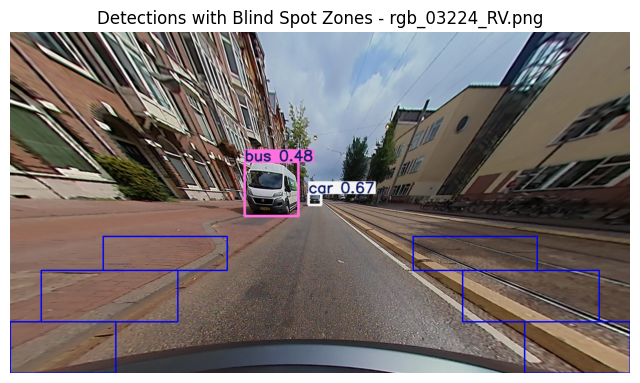

 No cars in blind spots.


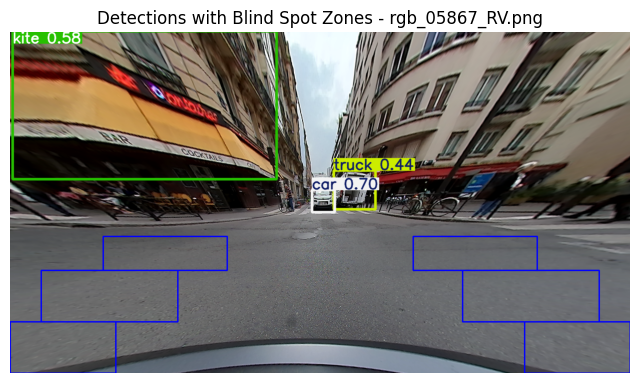

 No cars in blind spots.


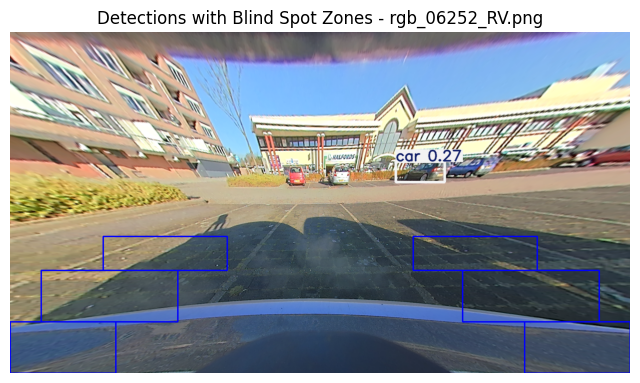

 No cars in blind spots.


In [12]:

def overlaps(a_xyxy, b_xyxy, touch_counts):
    ax1, ay1, ax2, ay2 = a_xyxy
    bx1, by1, bx2, by2 = b_xyxy
    w = min(ax2, bx2) - max(ax1, bx1)
    h = min(ay2, by2) - max(ay1, by1)
    return (w >= 0 and h >= 0) if touch_counts else (w > 0 and h > 0)

for img_file in test_images:

    img_path = os.path.join(rv_undistorted_dir, img_file)
    results = model(img_path, verbose=False)
    result = results[0]

    plotted = result.plot()
    h, w = plotted.shape[:2]

    # Right blindspot zones
    right_zone   = ((int(w * 0.83), int(h)),       (w, int(h * .85)))
    right_zone_2 = ((int(w * 0.73), int(h * 0.7)), (int(w*0.95), int(h * .85)))
    right_zone_3 = ((int(w * 0.65), int(h * 0.6)), (int(w*0.85), int(h * .7)))

    right_zones = [right_zone, right_zone_2, right_zone_3]

    # left blindspot zones 
    (x1, y1), (x2, y2) = right_zone
    left_zone = ((w - x2, y1), (w - x1, y2))

    (x1, y1), (x2, y2) = right_zone_2
    left_zone_2 = ((w - x2, y1), (w - x1, y2))

    (x1, y1), (x2, y2) = right_zone_3
    left_zone_3 = ((w - x2, y1), (w - x1, y2))

    left_zones = [left_zone, left_zone_2, left_zone_3]

    # Convert for overlap checking
    right_xyxys = [(z[0][0], z[0][1], z[1][0], z[1][1]) for z in right_zones]
    left_xyxys  = [(z[0][0], z[0][1], z[1][0], z[1][1]) for z in left_zones]

    left_alert = False
    right_alert = False

    # ---------------------- DETECTION ----------------------
    for box in result.boxes:
        cls_name = model.names[int(box.cls)].lower()
        if cls_name not in ("car", "bus"):
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        car_xyxy = (x1, y1, x2, y2)

        # check left zones
        for z in left_xyxys:
            if overlaps(car_xyxy, z, True):
                left_alert = True
                break

        # check right zones
        for z in right_xyxys:
            if overlaps(car_xyxy, z, True):
                right_alert = True
                break


    for zone in right_zones:
        cv2.rectangle(plotted, zone[0], zone[1], (255, 0, 0), 2)
    
    for zone in left_zones:
        cv2.rectangle(plotted, zone[0], zone[1], (255, 0, 0), 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"Detections with Blind Spot Zones - {img_file}")
    plt.axis('off')
    plt.show()

    # ---------------------- ALERTS ----------------------
    if left_alert:
        print("  Car detected in Right blind spot!")
    if right_alert:
        print("  Car detected in Left blind spot!")
    if not (left_alert or right_alert):
        print(" No cars in blind spots.")
